In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [12]:
DATA_DIR = Path.cwd().parent/'data'
results = pd.read_csv(DATA_DIR/'results.csv')
drivers = pd.read_csv(DATA_DIR/'processed_data'/'clean_drivers.csv')
races = pd.read_csv(DATA_DIR/'races.csv')
constructors = pd.read_csv(DATA_DIR/'constructors.csv')

In [13]:
win_stats = results.loc[results['positionOrder']==1]
win_stats

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
22,23,19,8,6,1,2,1,1,1,10.0,56,1:31:18.555,5478555,37,2,1:35.405,209.158,1
44,45,20,13,6,2,2,1,1,1,10.0,57,1:31:06.970,5466970,38,3,1:33.600,208.153,1
66,67,21,8,6,1,1,1,1,1,10.0,66,1:38:19.051,5899051,46,1,1:21.670,205.191,1
88,89,22,13,6,2,1,1,1,1,10.0,58,1:26:49.451,5209451,16,3,1:26.666,221.734,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26659,26665,1140,832,6,55,1,1,1,1,25.0,71,1:40:55.800,6055800,62,7,1:20.137,193.348,1
26679,26685,1141,830,9,1,17,1,1,1,26.0,69,2:06:54.430,7614430,67,1,1:20.472,192.767,1
26699,26705,1142,847,131,63,1,1,1,1,25.0,50,1:22:05.969,4925969,46,4,1:35.717,233.225,1
26719,26725,1143,830,9,1,2,1,1,1,25.0,57,1:31:05.323,5465323,55,2,1:22.905,235.310,1


In [14]:
win_stats = win_stats.merge(races[['raceId','date']], on='raceId', how='left')
win_stats

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,date
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008-03-16
1,23,19,8,6,1,2,1,1,1,10.0,56,1:31:18.555,5478555,37,2,1:35.405,209.158,1,2008-03-23
2,45,20,13,6,2,2,1,1,1,10.0,57,1:31:06.970,5466970,38,3,1:33.600,208.153,1,2008-04-06
3,67,21,8,6,1,1,1,1,1,10.0,66,1:38:19.051,5899051,46,1,1:21.670,205.191,1,2008-04-27
4,89,22,13,6,2,1,1,1,1,10.0,58,1:26:49.451,5209451,16,3,1:26.666,221.734,1,2008-05-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,26665,1140,832,6,55,1,1,1,1,25.0,71,1:40:55.800,6055800,62,7,1:20.137,193.348,1,2024-10-27
1124,26685,1141,830,9,1,17,1,1,1,26.0,69,2:06:54.430,7614430,67,1,1:20.472,192.767,1,2024-11-03
1125,26705,1142,847,131,63,1,1,1,1,25.0,50,1:22:05.969,4925969,46,4,1:35.717,233.225,1,2024-11-23
1126,26725,1143,830,9,1,2,1,1,1,25.0,57,1:31:05.323,5465323,55,2,1:22.905,235.310,1,2024-12-01


In [15]:
win_stats.dtypes

resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number              object
grid                 int64
position            object
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds        object
fastestLap          object
rank                object
fastestLapTime      object
fastestLapSpeed     object
statusId             int64
date                object
dtype: object

In [16]:
win_stats['date'] = pd.to_datetime(win_stats['date'])
win_stats['year'] = win_stats['date'].dt.year
win_stats['decade'] = (win_stats['year']//10)*10
win_stats

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,date,year,decade
0,1,18,1,1,22,1,1,1,1,10.0,...,1:34:50.616,5690616,39,2,1:27.452,218.300,1,2008-03-16,2008,2000
1,23,19,8,6,1,2,1,1,1,10.0,...,1:31:18.555,5478555,37,2,1:35.405,209.158,1,2008-03-23,2008,2000
2,45,20,13,6,2,2,1,1,1,10.0,...,1:31:06.970,5466970,38,3,1:33.600,208.153,1,2008-04-06,2008,2000
3,67,21,8,6,1,1,1,1,1,10.0,...,1:38:19.051,5899051,46,1,1:21.670,205.191,1,2008-04-27,2008,2000
4,89,22,13,6,2,1,1,1,1,10.0,...,1:26:49.451,5209451,16,3,1:26.666,221.734,1,2008-05-11,2008,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,26665,1140,832,6,55,1,1,1,1,25.0,...,1:40:55.800,6055800,62,7,1:20.137,193.348,1,2024-10-27,2024,2020
1124,26685,1141,830,9,1,17,1,1,1,26.0,...,2:06:54.430,7614430,67,1,1:20.472,192.767,1,2024-11-03,2024,2020
1125,26705,1142,847,131,63,1,1,1,1,25.0,...,1:22:05.969,4925969,46,4,1:35.717,233.225,1,2024-11-23,2024,2020
1126,26725,1143,830,9,1,2,1,1,1,25.0,...,1:31:05.323,5465323,55,2,1:22.905,235.310,1,2024-12-01,2024,2020


In [17]:
win_stats = win_stats.merge(drivers[['driverId','full_name']], on='driverId', how='left')
win_stats = win_stats.merge(constructors[['constructorId','name']], on='constructorId', how='left')
win_stats

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,date,year,decade,full_name,name
0,1,18,1,1,22,1,1,1,1,10.0,...,39,2,1:27.452,218.300,1,2008-03-16,2008,2000,Lewis Hamilton,McLaren
1,23,19,8,6,1,2,1,1,1,10.0,...,37,2,1:35.405,209.158,1,2008-03-23,2008,2000,Kimi Räikkönen,Ferrari
2,45,20,13,6,2,2,1,1,1,10.0,...,38,3,1:33.600,208.153,1,2008-04-06,2008,2000,Felipe Massa,Ferrari
3,67,21,8,6,1,1,1,1,1,10.0,...,46,1,1:21.670,205.191,1,2008-04-27,2008,2000,Kimi Räikkönen,Ferrari
4,89,22,13,6,2,1,1,1,1,10.0,...,16,3,1:26.666,221.734,1,2008-05-11,2008,2000,Felipe Massa,Ferrari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1123,26665,1140,832,6,55,1,1,1,1,25.0,...,62,7,1:20.137,193.348,1,2024-10-27,2024,2020,Carlos Sainz,Ferrari
1124,26685,1141,830,9,1,17,1,1,1,26.0,...,67,1,1:20.472,192.767,1,2024-11-03,2024,2020,Max Verstappen,Red Bull
1125,26705,1142,847,131,63,1,1,1,1,25.0,...,46,4,1:35.717,233.225,1,2024-11-23,2024,2020,George Russell,Mercedes
1126,26725,1143,830,9,1,2,1,1,1,25.0,...,55,2,1:22.905,235.310,1,2024-12-01,2024,2020,Max Verstappen,Red Bull


In [18]:
win_stats.to_csv(DATA_DIR/'processed_data'/'wins_stats.csv', index=False)

In [19]:
wins_per_decade =  win_stats.groupby(['decade','full_name']).size().reset_index(name='wins')
wins_per_decade

,decade,full_name,wins
0,1950,Alberto Ascari,13
1,1950,Bill Vukovich,2
2,1950,Bob Sweikert,1
3,1950,Bruce McLaren,1
4,1950,Jack Brabham,2
...,...,...,...
148,2020,Max Verstappen,55
149,2020,Oscar Piastri,2
150,2020,Pierre Gasly,1
151,2020,Sergio Pérez,6


In [26]:
most_wins_per_decade = wins_per_decade.sort_values(['decade','wins'], ascending=[True,False]).groupby('decade').head(1)
most_wins_per_decade

,decade,full_name,wins
9,1950,Juan Fangio,24
33,1960,Jim Clark,25
67,1970,Niki Lauda,17
74,1980,Alain Prost,39
105,1990,Michael Schumacher,35
123,2000,Michael Schumacher,56
134,2010,Lewis Hamilton,73
148,2020,Max Verstappen,55


In [27]:
most_wins_per_decade['decade'] = most_wins_per_decade['decade'].astype(str)+'s'

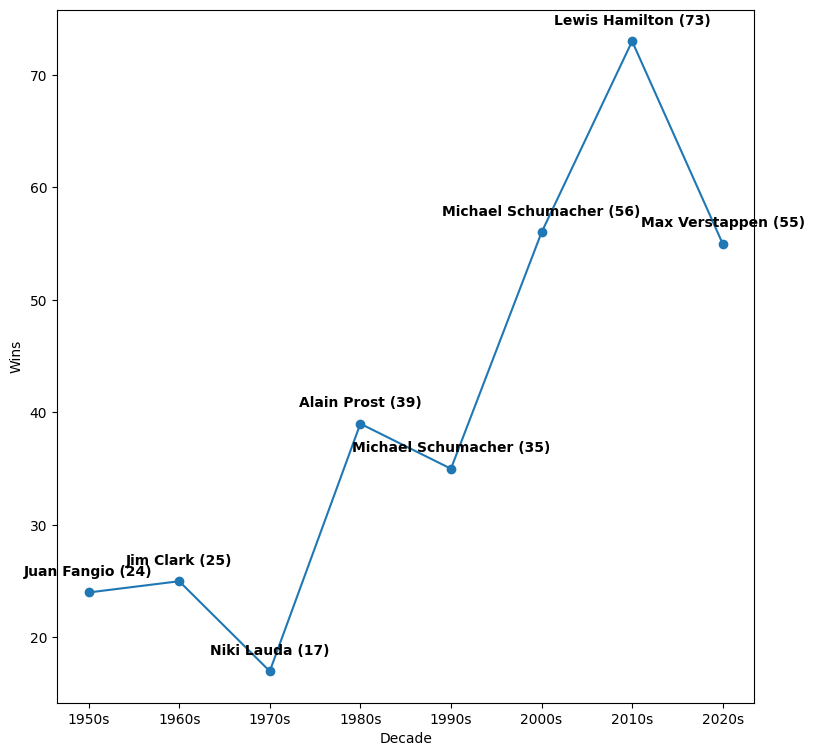

In [51]:
x = most_wins_per_decade['decade'].values.tolist()
y = most_wins_per_decade['wins'].values.tolist()
names = most_wins_per_decade['full_name'].values.tolist()

fig, ax = plt.subplots(figsize=(9,9))
ax.plot(x,y, marker='o')
ax.set_xlabel('Decade')
ax.set_ylabel('Wins')
for dec, win, dr in zip(x,y,names):
    ax.text(dec, win+1.5, f"{dr} ({win})", ha='center', fontsize=10, fontweight='bold')


plt.show()